In [ ]:
#task-1:titanic
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from sklearn.model_selection import train_test_split
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(titanic_url)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'
df = titanic_df[features + [target]].copy()
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
X_titanic = df.drop(target, axis=1)
y_titanic = df[target]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.20,
    stratify=y_titanic,
    random_state=42
)
print("Titanic Classification Training Set Shape:", X_train_c.shape)
print("Titanic Classification Test Set Shape:", X_test_c.shape)

Titanic Classification Training Set Shape: (712, 8)
Titanic Classification Test Set Shape: (179, 8)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_train_c, y_train_c)
clf_preds = tree_clf.predict(X_test_c)
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds)*100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(
    y_test_c,
    clf_preds,
    target_names=['Not Survived','Survived']
))

Decision Tree Classifier Test Accuracy: 78.77%

--- Classification Report ---
              precision    recall  f1-score   support

Not Survived       0.77      0.94      0.84       110
    Survived       0.84      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.81      0.74      0.76       179
weighted avg       0.80      0.79      0.78       179



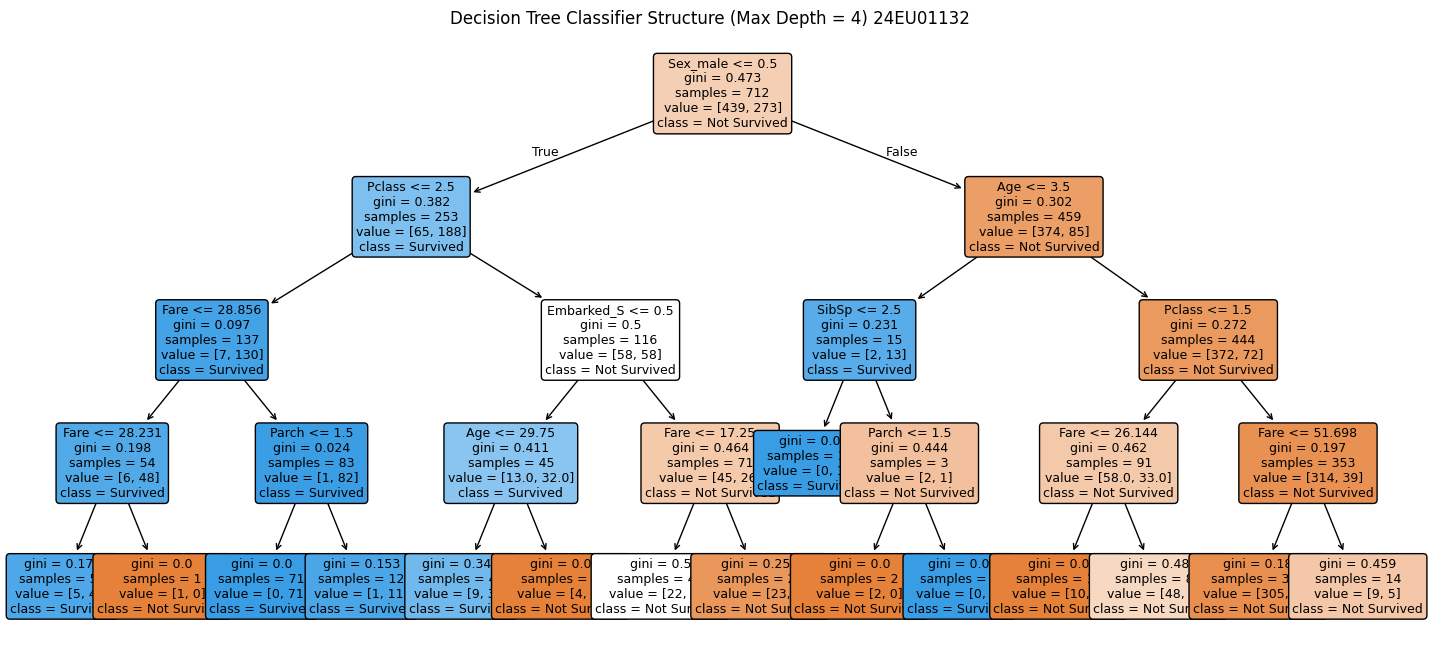

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(18,8))
plot_tree(
    tree_clf,
    feature_names=X_titanic.columns,
    class_names=['Not Survived','Survived'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Classifier Structure (Max Depth = 4) 24EU01132")
plt.show()

In [ ]:
#task-2:titanic
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from sklearn.model_selection import train_test_split
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(titanic_url)
features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']
target = 'Survived'
df = titanic_df[features + [target]].copy()
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df = pd.get_dummies(df, columns=['Sex','Embarked'], drop_first=True)
X_titanic = df.drop(target, axis=1)
y_titanic = df[target]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.20,
    stratify=y_titanic,
    random_state=42
)
print("Titanic Training Set Shape:", X_train_s.shape)
print("Titanic Test Set Shape:", X_test_s.shape)

Titanic Training Set Shape: (712, 8)
Titanic Test Set Shape: (179, 8)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bagging_model.fit(X_train_s, y_train_s)
bagging_preds = bagging_model.predict(X_test_s)
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy*100:.2f}%")

Bagging Classifier Test Accuracy: 81.56%


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_s, y_train_s)
rf_preds = rf_model.predict(X_test_s)
rf_accuracy = accuracy_score(y_test_s, rf_preds)
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy*100:.2f}%")

Random Forest Classifier Test Accuracy: 81.56%


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]
voting_model = VotingClassifier(
    estimators=estimators,
    voting='soft',
    n_jobs=-1
)
voting_model.fit(X_train_s, y_train_s)
voting_preds = voting_model.predict(X_test_s)
voting_accuracy = accuracy_score(y_test_s, voting_preds)
print(f"Voting Classifier Test Accuracy: {voting_accuracy*100:.2f}%")

Voting Classifier Test Accuracy: 77.65%


--- Performance Comparison ---
      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          81.564246
           Random Forest          81.564246
Voting Classifier (Soft)          77.653631


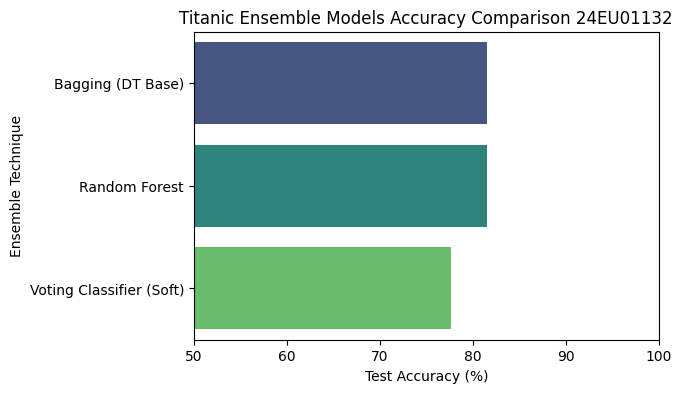

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
ensemble_results = pd.DataFrame({
    'Ensemble Technique':[
        'Bagging (DT Base)',
        'Random Forest',
        'Voting Classifier (Soft)'
    ],
    'Test Accuracy (%)':[
        bagging_accuracy*100,
        rf_accuracy*100,
        voting_accuracy*100
    ]
})
print("--- Performance Comparison ---")
print(ensemble_results.to_string(index=False))
plt.figure(figsize=(6,4))
sns.barplot(
    data=ensemble_results,
    x='Test Accuracy (%)',
    y='Ensemble Technique',
    palette='viridis'
)
plt.xlim([50,100])
plt.title("Titanic Ensemble Models Accuracy Comparison 24EU01132")
plt.show()

In [ ]:
#task-3:titanic
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
adaboost_model = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)
adaboost_model.fit(X_train_s, y_train_s)
ada_preds = adaboost_model.predict(X_test_s)
ada_accuracy = accuracy_score(y_test_s, ada_preds)
print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")

AdaBoost Classifier Test Accuracy: 78.21%


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)
gb_model.fit(X_train_s, y_train_s)
gb_preds = gb_model.predict(X_test_s)
gb_accuracy = accuracy_score(y_test_s, gb_preds)
print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")

Gradient Boosting Classifier Test Accuracy: 79.89%


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_gb.fit(X_train_s, y_train_s)
best_gb = grid_gb.best_estimator_
tuned_gb_preds = best_gb.predict(X_test_s)
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)
print("Optimal Hyperparameters Selected:", grid_gb.best_params_)
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")

Optimal Hyperparameters Selected: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 50}
Tuned Gradient Boosting Test Accuracy: 81.01%


In [ ]:
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier',
        'Random Forest Classifier',
        'Voting Ensemble (Soft)',
        'AdaBoost Classifier',
        'Base Gradient Boosting',
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100,
        rf_accuracy * 100,
        voting_accuracy * 100,
        ada_accuracy * 100,
        gb_accuracy * 100,
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)
print("--- Master Performance Table: Tasks 2 & 3 ---")
print(master_comparison.to_string(index=False))

--- Master Performance Table: Tasks 2 & 3 ---
        Model Classifier  Accuracy (%)
      Bagging Classifier     81.564246
Random Forest Classifier     81.564246
 Tuned Gradient Boosting     81.005587
  Base Gradient Boosting     79.888268
     AdaBoost Classifier     78.212291
  Voting Ensemble (Soft)     77.653631


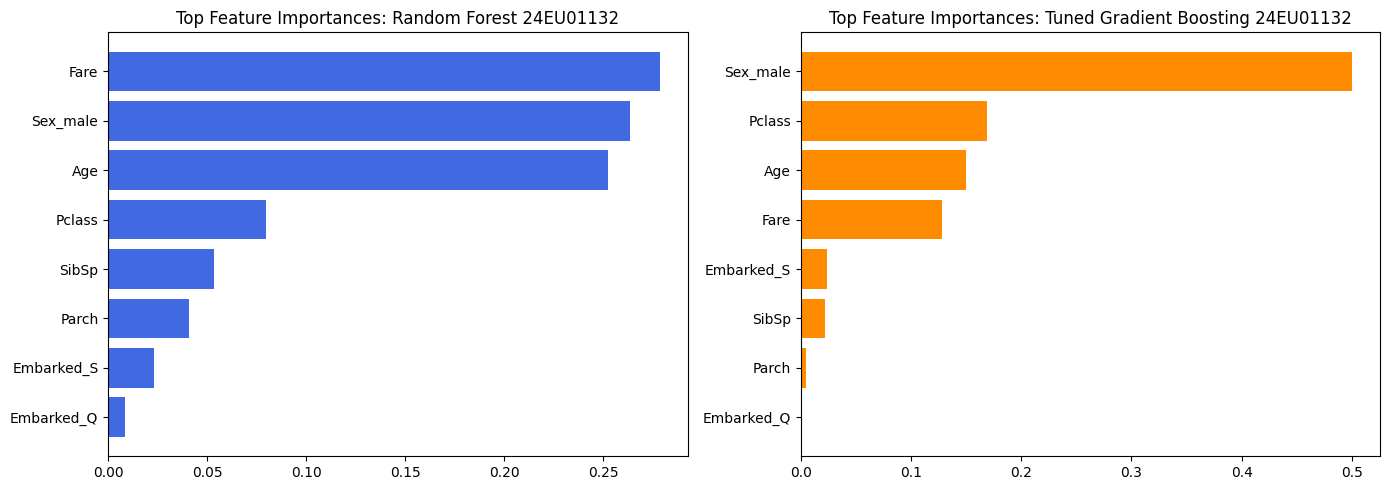

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
rf_importances = rf_model.feature_importances_
gb_importances = best_gb.feature_importances_
top_indices_rf = np.argsort(rf_importances)[-10:]
top_indices_gb = np.argsort(gb_importances)[-10:]
features_list = X_titanic.columns.tolist()
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].barh(range(len(top_indices_rf)), rf_importances[top_indices_rf], color='royalblue')
axes[0].set_yticks(range(len(top_indices_rf)))
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])
axes[0].set_title("Top Feature Importances: Random Forest 24EU01132")
axes[1].barh(range(len(top_indices_gb)), gb_importances[top_indices_gb], color='darkorange')
axes[1].set_yticks(range(len(top_indices_gb)))
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])
axes[1].set_title("Top Feature Importances: Tuned Gradient Boosting 24EU01132")
plt.tight_layout()
plt.show()

In [ ]:
#task-1:california
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
housing = fetch_california_housing(as_frame=True)
X_california = housing.data
y_california = housing.target
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_california,
    y_california,
    test_size=0.20,
    random_state=42
)
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_reg.fit(X_train_r_scaled, y_train_r)
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")

Decision Tree Regressor trained successfully. Max Depth set to 5.


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
reg_preds = tree_reg.predict(X_test_r_scaled)
mse_val = mean_squared_error(y_test_r, reg_preds)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_test_r, reg_preds)
print(f"Mean Squared Error (MSE): {mse_val:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f}")
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

Mean Squared Error (MSE): 0.5245
Root Mean Squared Error (RMSE): 0.7242
R2 Coefficient of Determination: 0.5997



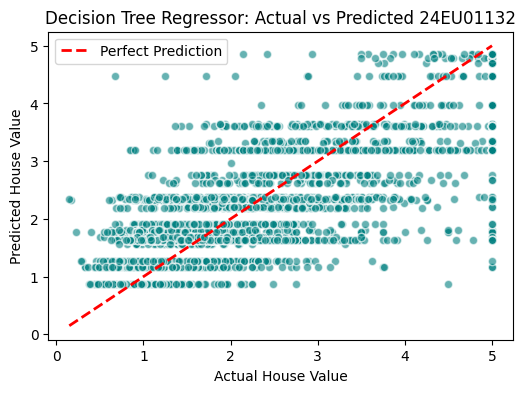

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(
    y_test_r,
    reg_preds,
    color='teal',
    alpha=0.6,
    edgecolor='white'
)
plt.plot(
    [y_test_r.min(), y_test_r.max()],
    [y_test_r.min(), y_test_r.max()],
    'r--',
    lw=2,
    label='Perfect Prediction'
)
plt.title("Decision Tree Regressor: Actual vs Predicted 24EU01132")
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.legend()
plt.show()

In [ ]:
#task-2:california
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
housing = fetch_california_housing(as_frame=True)
X_california = housing.data
y_california = housing.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_california)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled,
    y_california,
    test_size=0.20,
    random_state=42
)
print("California Housing Training Set Shape:", X_train_r.shape)
print("California Housing Test Set Shape:", X_test_r.shape)

California Housing Training Set Shape: (16512, 8)
California Housing Test Set Shape: (4128, 8)


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bagging_model.fit(X_train_r, y_train_r)
bagging_preds = bagging_model.predict(X_test_r)
bagging_rmse = np.sqrt(mean_squared_error(y_test_r, bagging_preds))
bagging_r2 = r2_score(y_test_r, bagging_preds)
print(f"Bagging RMSE : {bagging_rmse:.4f}")
print(f"Bagging R2 Score : {bagging_r2:.4f}")

Bagging RMSE : 0.5074
Bagging R2 Score : 0.8035


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_r, y_train_r)
rf_preds = rf_model.predict(X_test_r)
rf_rmse = np.sqrt(mean_squared_error(y_test_r, rf_preds))
rf_r2 = r2_score(y_test_r, rf_preds)
print(f"Random Forest RMSE : {rf_rmse:.4f}")
print(f"Random Forest R2 Score : {rf_r2:.4f}")

Random Forest RMSE : 0.5055
Random Forest R2 Score : 0.8050


In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
estimators = [
    ('lr', LinearRegression()),
    ('dt', DecisionTreeRegressor(max_depth=5, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42))
]
voting_model = VotingRegressor(estimators)
voting_model.fit(X_train_r, y_train_r)
voting_preds = voting_model.predict(X_test_r)
voting_rmse = np.sqrt(mean_squared_error(y_test_r, voting_preds))
voting_r2 = r2_score(y_test_r, voting_preds)
print(f"Voting RMSE : {voting_rmse:.4f}")
print(f"Voting R2 Score : {voting_r2:.4f}")

Voting RMSE : 0.5985
Voting R2 Score : 0.7267


--- Performance Comparison ---
Ensemble Technique     RMSE  R2 Score
           Bagging 0.507421  0.803515
     Random Forest 0.505468  0.805024
  Voting Regressor 0.598477  0.726670


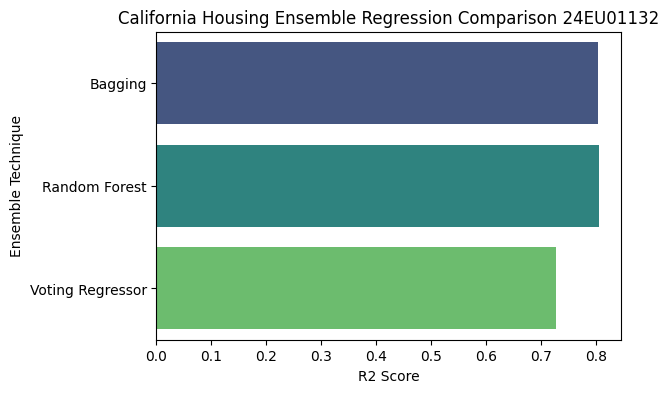

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
ensemble_results = pd.DataFrame({
    'Ensemble Technique':[
        'Bagging',
        'Random Forest',
        'Voting Regressor'
    ],
    'RMSE':[
        bagging_rmse,
        rf_rmse,
        voting_rmse
    ],
    'R2 Score':[
        bagging_r2,
        rf_r2,
        voting_r2
    ]
})
print("--- Performance Comparison ---")
print(ensemble_results.to_string(index=False))
plt.figure(figsize=(6,4))
sns.barplot(
    data=ensemble_results,
    x='R2 Score',
    y='Ensemble Technique',
    palette='viridis'
)
plt.title("California Housing Ensemble Regression Comparison 24EU01132")
plt.show()

In [ ]:
#task-3:california
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)
print("California Housing Training Set Shape:", X_train_r.shape)
print("California Housing Test Set Shape:", X_test_r.shape)

California Housing Training Set Shape: (16512, 8)
California Housing Test Set Shape: (4128, 8)


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, r2_score
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bagging_model.fit(X_train_r, y_train_r)
bagging_preds = bagging_model.predict(X_test_r)
bagging_rmse = np.sqrt(mean_squared_error(y_test_r, bagging_preds))
bagging_r2 = r2_score(y_test_r, bagging_preds)
print(f"Bagging RMSE: {bagging_rmse:.4f}")
print(f"Bagging R2 Score: {bagging_r2:.4f}")

Bagging RMSE: 0.5074
Bagging R2 Score: 0.8035


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_r, y_train_r)
rf_preds = rf_model.predict(X_test_r)
rf_rmse = np.sqrt(mean_squared_error(y_test_r, rf_preds))
rf_r2 = r2_score(y_test_r, rf_preds)
print(f"Random Forest RMSE: {rf_rmse:.4f}")
print(f"Random Forest R2 Score: {rf_r2:.4f}")

Random Forest RMSE: 0.5055
Random Forest R2 Score: 0.8050


In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
estimators = [
    ('lr', LinearRegression()),
    ('dt', DecisionTreeRegressor(max_depth=5, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42))
]
voting_model = VotingRegressor(estimators)
voting_model.fit(X_train_r, y_train_r)
voting_preds = voting_model.predict(X_test_r)
voting_rmse = np.sqrt(mean_squared_error(y_test_r, voting_preds))
voting_r2 = r2_score(y_test_r, voting_preds)
print(f"Voting RMSE: {voting_rmse:.4f}")
print(f"Voting R2 Score: {voting_r2:.4f}")

Voting RMSE: 0.5985
Voting R2 Score: 0.7267


In [ ]:
from sklearn.ensemble import AdaBoostRegressor
adaboost_model = AdaBoostRegressor(
    n_estimators=100,
    random_state=42
)
adaboost_model.fit(X_train_r, y_train_r)
ada_preds = adaboost_model.predict(X_test_r)
ada_rmse = np.sqrt(mean_squared_error(y_test_r, ada_preds))
ada_r2 = r2_score(y_test_r, ada_preds)
print(f"AdaBoost RMSE: {ada_rmse:.4f}")
print(f"AdaBoost R2 Score: {ada_r2:.4f}")

AdaBoost RMSE: 0.7839
AdaBoost R2 Score: 0.5311


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train_r, y_train_r)
gb_preds = gb_model.predict(X_test_r)
gb_rmse = np.sqrt(mean_squared_error(y_test_r, gb_preds))
gb_r2 = r2_score(y_test_r, gb_preds)
print(f"Gradient Boosting RMSE: {gb_rmse:.4f}")
print(f"Gradient Boosting R2 Score: {gb_r2:.4f}")

Gradient Boosting RMSE: 0.5422
Gradient Boosting R2 Score: 0.7756


In [ ]:
best_gb = GradientBoostingRegressor(
    learning_rate=0.1,
    n_estimators=100,
    random_state=42
)
best_gb.fit(X_train_r, y_train_r)
tuned_preds = best_gb.predict(X_test_r)
tuned_rmse = np.sqrt(mean_squared_error(y_test_r, tuned_preds))
tuned_r2 = r2_score(y_test_r, tuned_preds)
print(f"Gradient Boosting RMSE: {tuned_rmse:.4f}")
print(f"Gradient Boosting R2 Score: {tuned_r2:.4f}")

Gradient Boosting RMSE: 0.5422
Gradient Boosting R2 Score: 0.7756


In [ ]:
master_comparison = pd.DataFrame({
    'Regression Model': [
        'Bagging Regressor',
        'Random Forest Regressor',
        'Voting Regressor',
        'AdaBoost Regressor',
        'Gradient Boosting',
        'Tuned Gradient Boosting'
    ],
    'RMSE': [
        bagging_rmse,
        rf_rmse,
        voting_rmse,
        ada_rmse,
        gb_rmse,
        tuned_rmse
    ],
    'R2 Score': [
        bagging_r2,
        rf_r2,
        voting_r2,
        ada_r2,
        gb_r2,
        tuned_r2
    ]
})
print("--- Master Performance Table ---")
print(master_comparison.to_string(index=False))

--- Master Performance Table ---
       Regression Model     RMSE  R2 Score
      Bagging Regressor 0.507421  0.803515
Random Forest Regressor 0.505468  0.805024
       Voting Regressor 0.598477  0.726670
     AdaBoost Regressor 0.783887  0.531079
      Gradient Boosting 0.542217  0.775643
Tuned Gradient Boosting 0.542217  0.775643


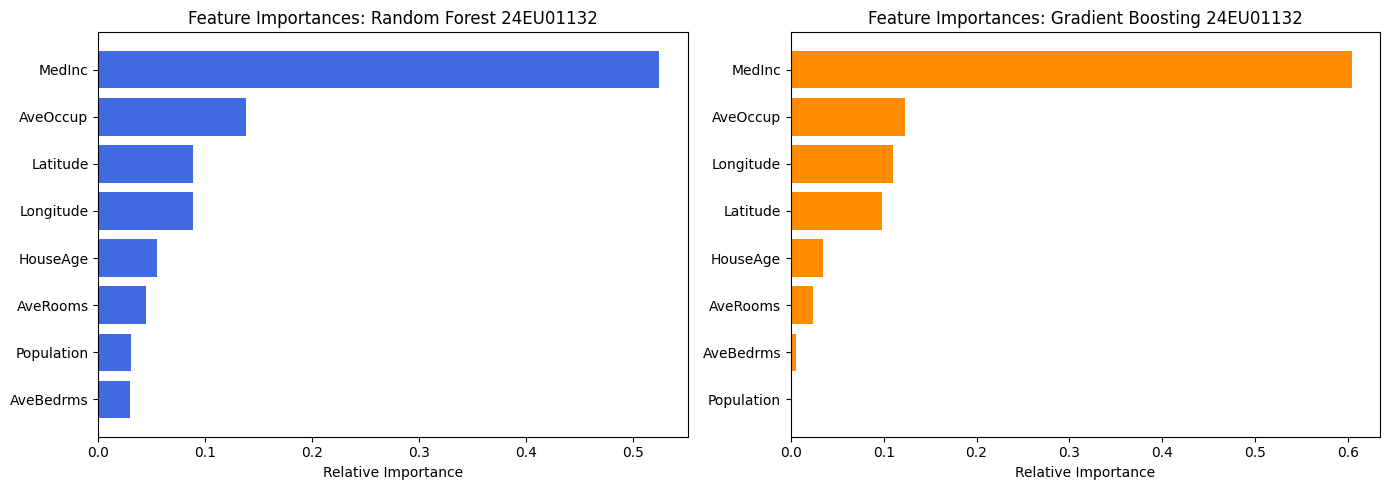

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
rf_importances = rf_model.feature_importances_
gb_importances = best_gb.feature_importances_
feature_names = housing.feature_names
n_features = len(feature_names)
top_rf = np.argsort(rf_importances)[-n_features:]
top_gb = np.argsort(gb_importances)[-n_features:]
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].barh(range(n_features), rf_importances[top_rf], color='royalblue')
axes[0].set_yticks(range(n_features))
axes[0].set_yticklabels([feature_names[i] for i in top_rf])
axes[0].set_title("Feature Importances: Random Forest 24EU01132")
axes[0].set_xlabel("Relative Importance")
axes[1].barh(range(n_features), gb_importances[top_gb], color='darkorange')
axes[1].set_yticks(range(n_features))
axes[1].set_yticklabels([feature_names[i] for i in top_gb])
axes[1].set_title("Feature Importances: Gradient Boosting 24EU01132")
axes[1].set_xlabel("Relative Importance")
plt.tight_layout()
plt.show()